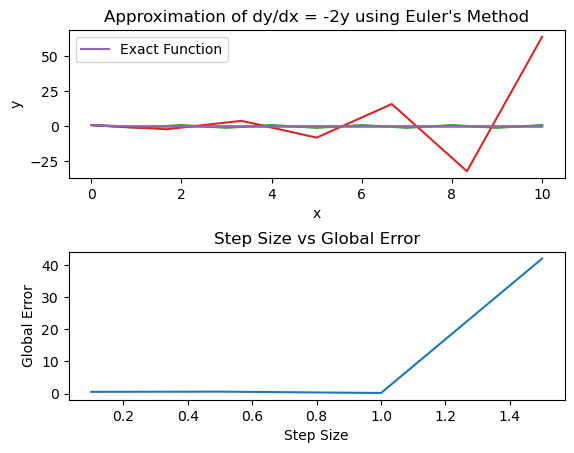

In [35]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the exact function
h = np.array([.1,.5,1.0,1.5]) # step size
x_start, x_end = 0, 10
num_steps = int((x_end - x_start) / h[0])
x = np.linspace(x_start, x_end, num_steps + 1)
y_exact=np.exp(-2*x)

#Define error functions
def local_error(y_values,y_exact):
    return (y_exact-y_values)
def global_error(local_error):
    return np.abs(np.sum(local_error))
#initialize global error array
globe=np.zeros(4)
#Loop through step sizes
for i in range (0,4):
    x_start, x_end = 0, 10
    num_steps = int((x_end - x_start) / h[i])
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    # Initial condition
    y_values[0] = 1 # y(0) = 1
    # Function representing dy/dx = -2y
    def f(x, y):
        return -2 * y
    y_exact1=np.exp(-2*x_values)
    # Implement Euler's method
    for j in range(num_steps):
        y_values[j + 1] = y_values[j] + h[i] *f(x_values[j], y_values[j])
    #Calculate error for each step
    local=local_error(y_values,y_exact1)
    globe[i]=global_error(local)
    #Plot euler's method for each step
    plt.subplot(2,1,1)
    plt.plot(x_values,y_values)
plt.plot(x,y_exact, label="Exact Function")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
#Plot Step Size vs Global Error
plt.subplot(2,1,2)
plt.plot(h,globe)
plt.title("Step Size vs Global Error")
plt.xlabel("Step Size")
plt.ylabel("Global Error")
plt.subplots_adjust(hspace=.5)
plt.show()